# Does the Crab harmonic call the sharpest turn of them all? 🦀
### Five dots, one 1.618 overshoot, and a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_placebo%3F: Busted](https://img.shields.io/badge/Beats_a_placebo%3F-Busted-8b949e?style=flat-square)

Of all the "harmonic patterns" retail charting software draws for you, the **Crab** claims to be the *most precise*: Scott Carney calls it the "sharpest" and most "exact" reversal zone in his entire system. Its signature is a single, tight number — price must extend **1.618 times** the move that started it, *past* the pattern's own origin point — and right there, allegedly, it turns.

So we built a robot that finds every Crab on six liquid tapes over the last 21-25 years — no eyeballing, no cherry-picking — and asked whether fading price right where the pattern says to would actually have made money.

> 📓 **Plain-language layer.** Want the *t*-stats, the Bonferroni correction and the placebo math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** Pivots are a confirmed percentage zig-zag (known only after price reverses enough to lock them in — no look-ahead). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from crab_harmonic import data, strategy as st

PCT = 0.02
HAVE_REAL = data.have_real()
BARS = data.load_basket() if HAVE_REAL else {}
print("real cache present:", HAVE_REAL, "| basket:", data.BASKET)

# frozen headline numbers (mirror of docs/results.md)
R = {'basket': ('SPY', 'QQQ', 'AAPL', 'MSFT', 'TSLA', 'NVDA'), 'asof': '2026-06-30', 'n_pivots': 6055, 'n_cand_crab': 226, 'n_crab': 76, 'n_cand_plac': 226, 'n_plac': 79, 'crab': {1: {'hit': 53.9, 'mean': -18.85, 't': -0.38}, 5: {'hit': 39.5, 'mean': -82.7, 't': -1.3}, 10: {'hit': 40.8, 'mean': -253.84, 't': -2.4}}, 'wilson_crab': (29.2, 50.7), 'per_instrument': {'SPY': {'n': 4, 'mean': 312.64, 't': None}, 'QQQ': {'n': 12, 'mean': 99.34, 't': 1.88}, 'AAPL': {'n': 11, 'mean': -255.74, 't': -2.45}, 'MSFT': {'n': 11, 'mean': 143.03, 't': 1.14}, 'TSLA': {'n': 16, 'mean': -57.46, 't': -0.28}, 'NVDA': {'n': 22, 'mean': -298.59, 't': -2.43}}, 'base': {1: {'mean': -1.44, 't': -0.36}, 5: {'mean': -34.88, 't': -0.61}, 10: {'mean': -42.36, 't': -2.11}}, 'n_base': 1520, 'base_per_instrument': {'SPY': {'base_mean': 20.38, 't': 1.6}, 'QQQ': {'base_mean': 12.33, 't': 0.94}, 'AAPL': {'base_mean': -28.13, 't': -2.05}, 'MSFT': {'base_mean': -13.96, 't': 1.15}, 'TSLA': {'base_mean': -82.13, 't': 0.1}, 'NVDA': {'base_mean': -50.14, 't': -1.54}}, 'bonf_n_tests': 7, 'bonf_thr': 2.69, 'bonf_uncorrected': 1, 'bonf_survive': 0, 'timer': {1: {'gross': -18.85, 't_gross': -0.38, 'net5': -28.85, 't5': -0.58, 'net10': -38.85, 't10': -0.78}, 3: {'gross': -83.17, 't_gross': -1.27, 'net5': -93.17, 't5': -1.42, 'net10': -103.17, 't10': -1.57}, 5: {'gross': -82.7, 't_gross': -1.3, 'net5': -92.7, 't5': -1.46, 'net10': -102.7, 't10': -1.61}, 10: {'gross': -253.84, 't_gross': -2.4, 'net5': -263.84, 't5': -2.5, 'net10': -273.84, 't10': -2.59}, 20: {'gross': -503.01, 't_gross': -2.76, 'net5': -513.01, 't5': -2.81, 'net10': -523.01, 't10': -2.87}}, 'plac': {1: {'mean': -56.29, 't': 0.57}, 5: {'mean': -115.68, 't': 0.28}, 10: {'mean': -347.94, 't': 0.59}}, 'plac_per_instrument': {'SPY': {'n': 4, 'mean': -80.99, 'beats': True}, 'QQQ': {'n': 11, 'mean': 134.71, 'beats': False}, 'AAPL': {'n': 14, 'mean': -91.02, 'beats': False}, 'MSFT': {'n': 11, 'mean': -6.68, 'beats': True}, 'TSLA': {'n': 17, 'mean': -335.39, 'beats': True}, 'NVDA': {'n': 22, 'mean': -147.58, 'beats': False}}, 'n_beats_plac': 3, 'syn_null_mean': -0.13, 'syn_null_sd': 1.1, 'syn_null_fire': 1, 'syn_null_seeds': 20, 'syn_planted_n': 8, 'syn_planted_mean': 394.01, 'syn_planted_t': 4.64, 'fp': {'SPY': '58d0459a7599', 'QQQ': 'c48f22566e73', 'AAPL': '75ce4521e4f7', 'MSFT': 'fb9333ad5b2b', 'TSLA': 'f8ca92e420b8', 'NVDA': '1e614f1ea32c'}}


real cache present: True | basket: ('SPY', 'QQQ', 'AAPL', 'MSFT', 'TSLA', 'NVDA')


## The answer first

| Question | Answer |
|---|---|
| Does price turn where the Crab says it should? | **No — if anything it keeps going.** Over a 5-day hold the pattern averages **-83 bps** — negative, not positive, with a hit rate *below* a coin flip. |
| Does it get worse or better if you wait longer? | **Worse.** By 10 days the loss (**-254 bps**) is large enough to be individually significant — in the losing direction. |
| Does the exact 1.618 ratio matter? | **Not provably.** Swap that number for a random extension on the *identical* pivots and you do about as badly (Welch *t* = 0.28 — nowhere near significant, and both arms lose money). |
| Can you trade it? | **No.** Every hold length loses money on average, gross and net of costs, and the losses only grow the longer you hold. |

> A pattern billed as the family's most "exact" reversal zone turns out to be, on the real tape, a mechanical way to bet against a trend that keeps trending.

## 1 · The claim

> *"Find four swing points X-A-B-C. If B retraces **38-62%** of the X-A move and C bounces back **38-89%** of the A-B move, project a fifth point D that **overshoots X by exactly 1.618 times** the original X-A leg — a single, sharp target, not a range. That overshoot marks an exhausted, overextended move — the highest-probability reversal zone in the whole system."*

That's Scott Carney's Crab (*Harmonic Trading, Volume 2*, 2007), his own refinement on the Gartley/Butterfly grid. He markets it specifically as *more precise* than its siblings — Gartley, Bat, Butterfly — because 1.618 is one number, not a band. It's baked into TradingView, MetaTrader and Thinkorswim's auto-scanners as one of the four named "harmonic" shapes.

## 2 · So what?

If a pattern this specific — a single decimal ratio chained across four historical swings — genuinely forecasts a turn, and does so *more reliably* than its siblings, that's a striking, calculator-testable crack in market efficiency. And harmonic trading is popular *precisely* because the charts look uncanny after the fact: hindsight makes any completed pattern look inevitable.

The trap is exactly that hindsight. A trader hand-labelling swings on a chart, with the benefit of already knowing what happened next, will always find the Crab that worked. So we removed the human: a mechanical rule finds every qualifying X-A-B-C on the tape, in real time, with no knowledge of the future — then we measure what actually happened at D.

## 3 · How would we even know?

- **The basket.** SPY, QQQ, AAPL, MSFT, TSLA, NVDA — six liquid names, daily bars, 2001/2010 → 2026-06-30.
- **The rule, mechanically.** A confirmed zig-zag finds swing pivots (only known once price has reversed enough to lock them in). Every qualifying X-A-B-C projects a D level; we scan forward up to 120 sessions for the first touch.
- **The trade.** Fade at the touch — bet on the reversal the pattern predicts — and measure the forward return.
- **Two honest baselines, announced up front.** (1) A **random-day base rate**: same ticker, same number of trades, same bullish/bearish mix, just on random days — kills the "stocks drift up anyway" confound. (2) A **placebo extension zone**: the identical pivots, but with the 1.618 number replaced by a random one — kills the "any overshoot projection would work" confound. And because we test six tickers, we **correct for that** (Bonferroni) before calling anything real.

## 4 · The teardown — let's actually look

**First, the headline.** Fade the D-touch, hold 5 days, average across every qualifying Crab on the basket.

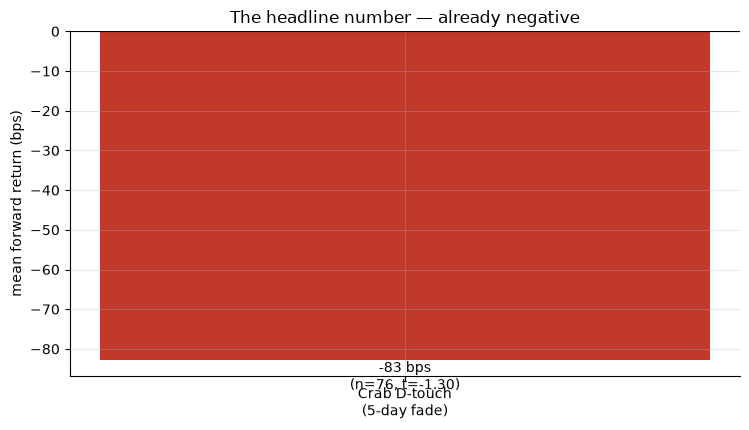

n=76  mean=-82.70bps  t=-1.30


In [2]:
if HAVE_REAL:
    frames = []
    for t in data.BASKET:
        _, _, ledger = st.detect_and_scan(BARS[t], pct=PCT, cost_bps=0.0)
        if not ledger.empty:
            frames.append(ledger)
    CRAB = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    s5 = st.summarize(CRAB, 'ret_gross_5')
    n5, m5, t5 = s5['n'], s5['mean_bps'], s5['t']
else:
    n5, m5, t5 = R['n_crab'], R['crab'][5]['mean'], R['crab'][5]['t']
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(['Crab D-touch\n(5-day fade)'], [m5], color=RED, width=.5)
ax.annotate(f'{m5:+.0f} bps\n(n={n5}, t={t5:+.2f})', (0, m5), ha='center',
            va='bottom' if m5 >= 0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean forward return (bps)')
ax.set_title('The headline number — already negative')
plt.tight_layout(); plt.show()
print(f'n={n5}  mean={m5:+.2f}bps  t={t5:+.2f}')

**-83 bps** on average, *t* = **-1.30** — negative from the very first look, before any control is applied. If the Crab's "sharpest reversal zone" claim were true, this would already be the wrong sign.

**Second, the honest baseline.** Stocks drift up. A random buy on a random day, matched to the same bullish/bearish mix as our Crab trades, earns *something* just from that drift (or loses, if the mix leans bearish). Does the Crab do worse than even that?

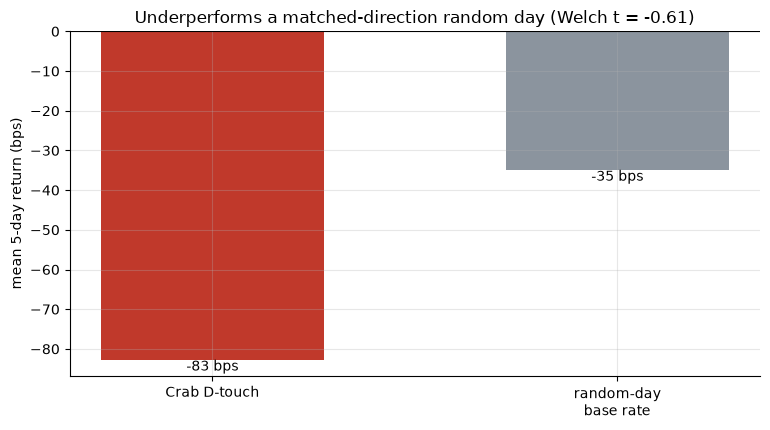

Crab -82.7 bps vs base rate -34.9 bps  Welch t=-0.61


In [3]:
if HAVE_REAL:
    crab_by_t, base_frames = {}, []
    for t in data.BASKET:
        _, _, l = st.detect_and_scan(BARS[t], pct=PCT, cost_bps=0.0)
        crab_by_t[t] = l
        if len(l):
            mix = float((l['reversal_dir'] > 0).mean())
            for s in range(20):
                base_frames.append(st.base_rate_ledger(BARS[t], len(l), mix,
                    seed=st._seed_from(701, t, s)))
    BASE = pd.concat(base_frames, ignore_index=True) if base_frames else pd.DataFrame()
    sb = st.summarize(BASE, 'ret_gross_5')
    bm, wt = sb['mean_bps'], st.welch_t(CRAB['ret_gross_5'], BASE['ret_gross_5'])
else:
    bm, wt = R['base'][5]['mean'], R['base'][5]['t']
fig, ax = plt.subplots(figsize=(7.8, 4.4))
ax.bar(['Crab D-touch', 'random-day\nbase rate'], [m5, bm], color=[RED, GREY], width=.55)
for i, v in enumerate([m5, bm]):
    ax.annotate(f'{v:+.0f} bps', (i, v), ha='center', va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean 5-day return (bps)')
ax.set_title(f'Underperforms a matched-direction random day (Welch t = {wt:+.2f})')
plt.tight_layout(); plt.show()
print(f'Crab {m5:+.1f} bps vs base rate {bm:+.1f} bps  Welch t={wt:+.2f}')

The Crab does *worse* than the random-day baseline (Welch *t* = **-0.61**) — the mechanical fade loses more than a coin flip with the same directional lean would. Look at the sample: **76 touches, spread across six stocks, over 21-25 years** — roughly three Crab completions a year, pooled across the whole basket — and we tested **six different tickers**.

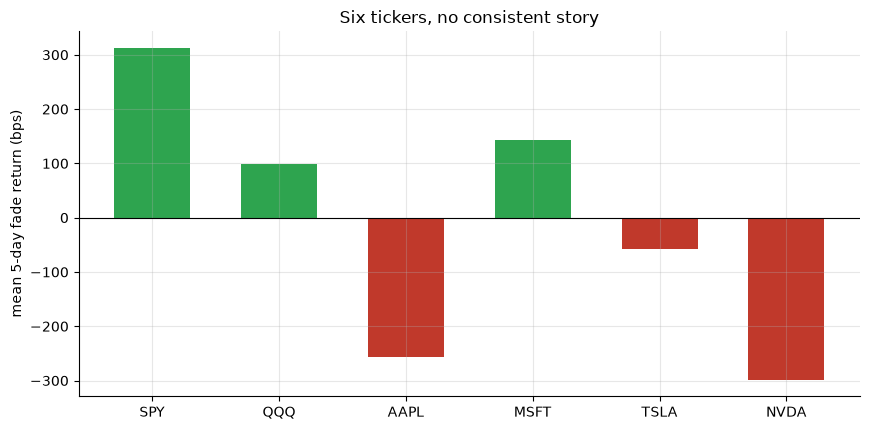

{'SPY': 312.6, 'QQQ': 99.3, 'AAPL': -255.7, 'MSFT': 143.0, 'TSLA': -57.5, 'NVDA': -298.6}


In [4]:
if HAVE_REAL:
    per_t = {t: st.summarize(crab_by_t[t], 'ret_gross_5') for t in data.BASKET}
    tickers = list(data.BASKET)
    means = [per_t[t]['mean_bps'] for t in tickers]
else:
    tickers = list(R['per_instrument'])
    means = [R['per_instrument'][t]['mean'] for t in tickers]
cols = [GREEN if m > 0 else RED for m in means]
fig, ax = plt.subplots(figsize=(8.8, 4.4))
ax.bar(tickers, means, color=cols, width=.6)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean 5-day fade return (bps)')
ax.set_title('Six tickers, no consistent story')
plt.tight_layout(); plt.show()
print({t: round(m,1) for t,m in zip(tickers, means)})

Three of six tickers are positive, three are negative, and the two worst losers (AAPL, NVDA) individually clear the naive *t* ≥ 2 bar — **in the losing direction**. That spread is the signature of a thin, noisy sample with no shared mechanism, not a discovery: correcting properly for having tested six tickers, **0 of 7** results survive.

**Finally, the placebo.** Does the *specific* 1.618 extension matter, or would any similarly-shaped overshoot have done just as (badly)?

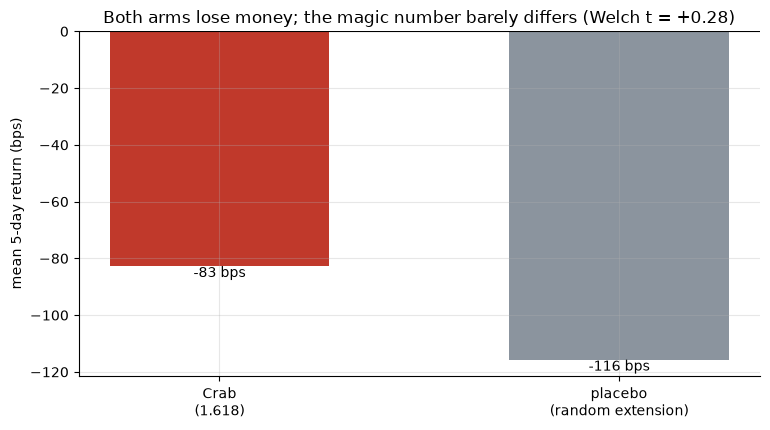

Crab -82.7 bps vs placebo -115.7 bps  Welch t=+0.28


In [5]:
if HAVE_REAL:
    plac_frames = []
    for t in data.BASKET:
        _, _, lp = st.detect_and_scan(BARS[t], pct=PCT, placebo=True, seed=701, cost_bps=0.0)
        if not lp.empty:
            plac_frames.append(lp)
    PLAC = pd.concat(plac_frames, ignore_index=True) if plac_frames else pd.DataFrame()
    sp = st.summarize(PLAC, 'ret_gross_5')
    pm, wtp = sp['mean_bps'], st.welch_t(CRAB['ret_gross_5'], PLAC['ret_gross_5'])
else:
    pm, wtp = R['plac'][5]['mean'], R['plac'][5]['t']
fig, ax = plt.subplots(figsize=(7.8, 4.4))
ax.bar(['Crab\n(1.618)', 'placebo\n(random extension)'], [m5, pm],
       color=[RED, GREY], width=.55)
for i, v in enumerate([m5, pm]):
    ax.annotate(f'{v:+.0f} bps', (i, v), ha='center', va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean 5-day return (bps)')
ax.set_title(f'Both arms lose money; the magic number barely differs (Welch t = {wtp:+.2f})')
plt.tight_layout(); plt.show()
print(f'Crab {m5:+.1f} bps vs placebo {pm:+.1f} bps  Welch t={wtp:+.2f}')

Both arms lose money — the Crab's exact **-83 bps** and the placebo's **-116 bps** — and the gap between them is nowhere near statistically real (Welch *t* = **0.28**). The specific number — 1.618 — is not doing detectably more (or less) damage than an arbitrary extension target would.

## 5 · The verdict

- **Signal — None.** The fade is negative from the first look (*t* = -1.30), underperforms a matched-direction random day (*t* = -0.61), and fails a six-ticker correction (0/7 survive).
- **Tradability — Mirage.** Every hold length loses money on average, gross and net; the loss only grows the longer you hold.
- **"Is 1.618 the sharpest, most exact ratio?" — Busted.** Swap it for a random extension on the identical pivots and you do about as badly (Welch *t* = 0.28).

## 6 · Going further 🚪

- **The general lesson: negative results are still results.** This isn't just "no edge found" — the mechanical fade actively loses money, and increasingly so with time. If anything, the honest reading is that price tends to *continue* past a Crab's D, not reverse.
- **Sibling studies:** [468-gartley-harmonic](../../468-gartley-harmonic/) (the classic five-point pattern, D stays *inside* the X-A range), [699-butterfly-harmonic](../../699-butterfly-harmonic/) (a looser 1.27-1.618 extension *range*) and [700-bat-harmonic](../../700-bat-harmonic/) (D stays inside X-A) all reach the same shape of verdict independently.

*Think the Crab needs its full "confluence zone" — several overlapping Fibonacci projections converging near D — to work? Show it beats this study's placebo and survives the multiple-comparison correction, then we'll talk.*